# Phase D — TDP-43 Measurement (N:C Ratio)

**Dataset:** WARD00034-R2 (`5c6bf125`), 249,465 cells
**Readout:** Nuclear-to-cytoplasmic ratio = nucleus_mean_bg / cytoplasm_mean_bg
**Interpretation:** High N:C = healthy nuclear TDP-43; low N:C = cytoplasmic mislocalization

Sources: `3_tdp43_localization.py` — three concentric disk compartments (r=4.5, 9, 18 µm)

In [ ]:
%matplotlib inline
from pathlib import Path
import numpy as np, pandas as pd, tifffile
import matplotlib.pyplot as plt, matplotlib.colors as mc
from matplotlib.colors import LinearSegmentedColormap
from skimage.filters import laplace

REPO    = Path('/Users/pmihack/claire/hs-array')
UUID    = '5c6bf125-6e0f-41be-a447-b03ff294c9cc'
TDP_PAR = REPO / f'outputs/tdp43_localization/{UUID}_tdp43_localization_20260806.parquet'
PMAPCSV = REPO / 'resources/plate_maps/remap_d28_rep1.csv'
IMG_DIR = REPO / 'data/D28_AB_Rep1' / UUID / 'images'
FIGDIR  = Path('/Users/pmihack/claire/hs-array/resources/iNDI_microscopy_production/notebooks/figures/phase_D')
FIGDIR.mkdir(parents=True, exist_ok=True)

PX_UM = 0.2967; DPI = 96; BG = 'black'; FG = 'white'
R_NUC_UM = 4.5; R_ADJ_UM = 9.0; R_CYTO_UM = 18.0
R_NUC = R_NUC_UM / PX_UM; R_ADJ = R_ADJ_UM / PX_UM; R_CYTO = R_CYTO_UM / PX_UM

## Setup — Load TDP-43 Localization Parquet

In [2]:
tdp = pd.read_parquet(TDP_PAR)
print(f"Columns:  {list(tdp.columns)}")
print(f"n_cells:  {len(tdp):,}")
print(f"n_wells:  {tdp[['Row','Column']].drop_duplicates().shape[0]}")
print()
print("NC_ratio stats (raw):")
print(tdp['NC_ratio'].describe().to_string())

# Join plate map
pmap = pd.read_csv(PMAPCSV)
pmap['Row']    = pmap.Well.str[0].apply(lambda x: ord(x)-64)
pmap['Column'] = pmap.Well.str[1:].astype(int)
pmap1 = pmap[pmap.Plate == 1][['Row','Column','Gene']]
tdp   = tdp.merge(pmap1, on=['Row','Column'], how='left')
print(f"\nGenes in plate map: {tdp['Gene'].nunique()}")
print(f"NT wells: {tdp[tdp.Gene.str.startswith('NT',na=False)]['Gene'].nunique()} variants")

# Filter to reasonable NC range
tdp_filt = tdp[(tdp.NC_ratio > 0) & (tdp.NC_ratio < 50)].copy()
print(f"\nAfter filtering NC_ratio 0–50: {len(tdp_filt):,} cells ({len(tdp_filt)/len(tdp)*100:.1f}%)")

Columns:  ['NC_ratio', 'adj_nuc_ratio', 'bg_tdp', 'tdp_nuc_mean', 'tdp_nuc_median', 'tdp_nuc_sum', 'tdp_nuc_std', 'tdp_nuc_n', 'tdp_nuc_mean_bg', 'tdp_adj_mean', 'tdp_adj_median', 'tdp_adj_sum', 'tdp_adj_std', 'tdp_adj_n', 'tdp_adj_mean_bg', 'tdp_cyto_mean', 'tdp_cyto_median', 'tdp_cyto_sum', 'tdp_cyto_std', 'tdp_cyto_n', 'tdp_cyto_mean_bg', 'Row', 'Column', 'Frame', 'Nucleus_ID', 'centroid-0', 'centroid-1', 'best_focus_plane', 'Measurement_ID']
n_cells:  249,465
n_wells:  192

NC_ratio stats (raw):
count    249367.000000
mean         20.795080
std         710.110695
min          -1.555282
25%           1.923617
50%           5.782728
75%          17.246370
max      352112.380420

Genes in plate map: 64
NT wells: 6 variants

After filtering NC_ratio 0–50: 226,507 cells (90.8%)


## Step 9 — Per-Compartment Intensity Measurement

Measurement logic (from 3_tdp43_localization.py):

  bg = np.percentile(tdp_plane, BG_PERCENTILE=5)  # 5th-percentile background
  nuc_mean_bg  = nuc_pixels.mean()  - bg
  cyto_mean_bg = cyto_pixels.mean() - bg
  NC_ratio = nuc_mean_bg / cyto_mean_bg

Example cell: r03c03 f01  Nucleus_ID=4
  bg_tdp:            163.0
  tdp_nuc_mean:      14219.1  (raw) → bg-subtracted: 14056.1
  tdp_adj_mean:      11132.1  → bg-subtracted: 10969.1
  tdp_cyto_mean:     2349.2 → bg-subtracted: 2186.2
  NC_ratio:          6.429
  adj_nuc_ratio:     0.780


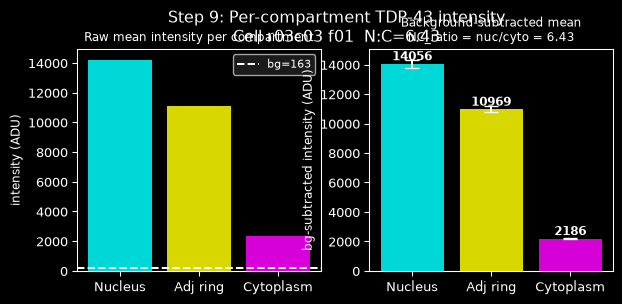

Saved: 01_per_compartment_intensity.png


In [3]:
# Show measurement logic using 3_tdp43_localization.py notation
print("Measurement logic (from 3_tdp43_localization.py):")
print()
print("  bg = np.percentile(tdp_plane, BG_PERCENTILE=5)  # 5th-percentile background")
print("  nuc_mean_bg  = nuc_pixels.mean()  - bg")
print("  cyto_mean_bg = cyto_pixels.mean() - bg")
print("  NC_ratio = nuc_mean_bg / cyto_mean_bg")
print()

# Pick one example cell with known NC_ratio
ex = tdp_filt[(tdp_filt.NC_ratio > 4) & (tdp_filt.NC_ratio < 7)].iloc[0]
print(f"Example cell: r{int(ex.Row):02d}c{int(ex.Column):02d} f{int(ex.Frame):02d}  "
      f"Nucleus_ID={int(ex.Nucleus_ID)}")
print(f"  bg_tdp:            {ex.bg_tdp:.1f}")
print(f"  tdp_nuc_mean:      {ex.tdp_nuc_mean:.1f}  (raw) → bg-subtracted: {ex.tdp_nuc_mean_bg:.1f}")
print(f"  tdp_adj_mean:      {ex.tdp_adj_mean:.1f}  → bg-subtracted: {ex.tdp_adj_mean_bg:.1f}")
print(f"  tdp_cyto_mean:     {ex.tdp_cyto_mean:.1f} → bg-subtracted: {ex.tdp_cyto_mean_bg:.1f}")
print(f"  NC_ratio:          {ex.NC_ratio:.3f}")
print(f"  adj_nuc_ratio:     {ex.adj_nuc_ratio:.3f}")

# Bar chart: per-compartment intensities for this cell
fig, axs = plt.subplots(1, 2, figsize=(7.2, 3.0), facecolor=BG, dpi=DPI)
fig.suptitle(f'Step 9: Per-compartment TDP-43 intensity\n'
             f'Cell r{int(ex.Row):02d}c{int(ex.Column):02d} f{int(ex.Frame):02d}  N:C={ex.NC_ratio:.2f}',
             color=FG, y=1.02)
for ax in axs:
    ax.set_facecolor(BG); ax.tick_params(colors=FG); ax.xaxis.label.set_color(FG); ax.yaxis.label.set_color(FG)
    for s in ax.spines.values(): s.set_color(FG)

compartments = ['Nucleus', 'Adj ring', 'Cytoplasm']
raw_means = [ex.tdp_nuc_mean, ex.tdp_adj_mean, ex.tdp_cyto_mean]
bg_means  = [ex.tdp_nuc_mean_bg, ex.tdp_adj_mean_bg, ex.tdp_cyto_mean_bg]
stds      = [ex.tdp_nuc_std, ex.tdp_adj_std, ex.tdp_cyto_std]
colors    = ['cyan', 'yellow', 'magenta']

axs[0].bar(compartments, raw_means, color=colors, alpha=0.85, edgecolor='none')
axs[0].axhline(ex.bg_tdp, color='white', ls='--', lw=1.5, label=f'bg={ex.bg_tdp:.0f}')
axs[0].set_title('Raw mean intensity per compartment', color=FG, fontsize=9)
axs[0].set_ylabel('intensity (ADU)', fontsize=9)
axs[0].legend(fontsize=8, labelcolor=FG, facecolor='#222')

axs[1].bar(compartments, bg_means, color=colors, alpha=0.85, edgecolor='none',
           yerr=[s/np.sqrt(n) for s, n in [(ex.tdp_nuc_std, ex.tdp_nuc_n),
                                             (ex.tdp_adj_std, ex.tdp_adj_n),
                                             (ex.tdp_cyto_std, ex.tdp_cyto_n)]],
           capsize=5, error_kw={'ecolor':'white', 'lw':1.5})
axs[1].set_title(f'Background-subtracted mean\nNC_ratio = nuc/cyto = {ex.NC_ratio:.2f}', color=FG, fontsize=9)
axs[1].set_ylabel('bg-subtracted intensity (ADU)', fontsize=9)
for i, (comp, val) in enumerate(zip(compartments, bg_means)):
    axs[1].text(i, val+50, f'{val:.0f}', ha='center', va='bottom', color=FG, fontsize=9, fontweight='bold')

fig.savefig(FIGDIR / '01_per_compartment_intensity.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: 01_per_compartment_intensity.png")

## Step 10 — Derived Readouts: N:C Ratio Distribution

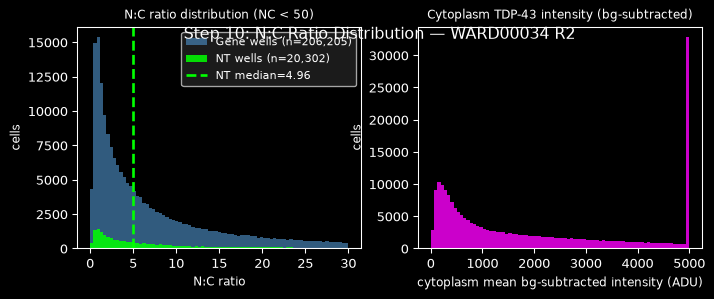

NT median N:C: 4.96
Overall median N:C: 4.81


In [4]:
# N:C ratio distribution, colored by NT vs other
nt_mask   = tdp_filt.Gene.str.startswith('NT', na=False)
nt_df     = tdp_filt[nt_mask]
gene_df   = tdp_filt[~nt_mask]
nt_median = nt_df.NC_ratio.median()

fig, axs = plt.subplots(1, 2, figsize=(8.4, 3.0), facecolor=BG, dpi=DPI)
fig.suptitle('Step 10: N:C Ratio Distribution — WARD00034 R2', color=FG, y=0.88)
for ax in axs:
    ax.set_facecolor(BG); ax.tick_params(colors=FG); ax.xaxis.label.set_color(FG); ax.yaxis.label.set_color(FG)
    for s in ax.spines.values(): s.set_color(FG)

bins = np.linspace(0, 30, 80)
axs[0].hist(gene_df.NC_ratio, bins=bins, color='steelblue', alpha=0.7, edgecolor='none', label=f'Gene wells (n={len(gene_df):,})')
axs[0].hist(nt_df.NC_ratio,   bins=bins, color='lime',      alpha=0.85, edgecolor='none', label=f'NT wells (n={len(nt_df):,})')
axs[0].axvline(nt_median, color='lime', ls='--', lw=2, label=f'NT median={nt_median:.2f}')
axs[0].set_xlabel('N:C ratio', fontsize=9); axs[0].set_ylabel('cells', fontsize=9)
axs[0].set_title('N:C ratio distribution (NC < 50)', color=FG, fontsize=9)
axs[0].legend(fontsize=8, labelcolor=FG, facecolor='#222')

# Cytoplasm mean intensity distribution
axs[1].hist(tdp_filt.tdp_cyto_mean_bg.clip(-500, 5000), bins=80, color='magenta', alpha=0.8, edgecolor='none')
axs[1].set_xlabel('cytoplasm mean bg-subtracted intensity (ADU)', fontsize=9)
axs[1].set_ylabel('cells', fontsize=9)
axs[1].set_title('Cytoplasm TDP-43 intensity (bg-subtracted)', color=FG, fontsize=9)

fig.savefig(FIGDIR / '02_nc_ratio_distribution.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"NT median N:C: {nt_median:.2f}")
print(f"Overall median N:C: {tdp_filt.NC_ratio.median():.2f}")

## Step 11 — Background Subtraction

TDP-43 field r09c05 f05:
  5th-percentile background: 143.0 ADU  ← used in script
  Mean:                      1126.0 ADU  (biased high by bright cells)
  Median:                    196.0 ADU  (less biased, but still affected)
  Max (99th pct):            26495.0 ADU


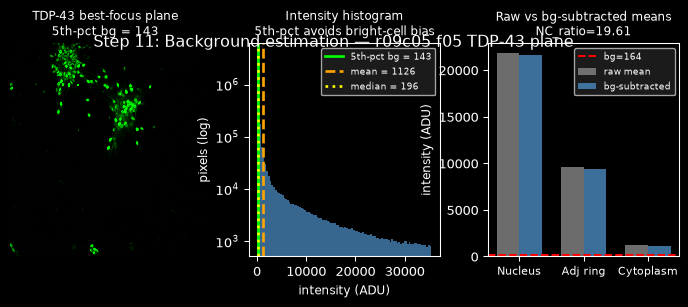

Saved: 03_background_subtraction.png


In [5]:
# Demonstrate 5th-percentile background estimate on one TDP-43 field
# Use a well with both NT label
nt_well = nt_df.groupby(['Row','Column']).size().idxmax()
row_bg, col_bg = int(nt_well[0]), int(nt_well[1])
subdir_bg = IMG_DIR / f'r{row_bg:02d}c{col_bg:02d}'
tdp_paths_bg = sorted(subdir_bg.glob(f'r{row_bg:02d}c{col_bg:02d}f05p*-ch03t01.tiff'))

if not tdp_paths_bg:
    tdp_paths_bg = sorted(subdir_bg.glob(f'r{row_bg:02d}c{col_bg:02d}f01p*-ch03t01.tiff'))

if tdp_paths_bg:
    planes_bg = [tifffile.imread(p).astype(np.float32) for p in tdp_paths_bg]
    focus_bg  = [np.var(laplace(p)) for p in planes_bg]
    tdp_plane = planes_bg[int(np.argmax(focus_bg))]
else:
    tdp_plane = np.random.randint(100, 2000, (2160, 2160), dtype=np.uint16).astype(np.float32)

bg_5pct   = np.percentile(tdp_plane, 5)
bg_mean   = float(tdp_plane.mean())
bg_median = float(np.median(tdp_plane))

print(f"TDP-43 field r{row_bg:02d}c{col_bg:02d} f05:")
print(f"  5th-percentile background: {bg_5pct:.1f} ADU  ← used in script")
print(f"  Mean:                      {bg_mean:.1f} ADU  (biased high by bright cells)")
print(f"  Median:                    {bg_median:.1f} ADU  (less biased, but still affected)")
print(f"  Max (99th pct):            {np.percentile(tdp_plane, 99):.1f} ADU")

fig, axs = plt.subplots(1, 3, figsize=(9.0, 3.0), facecolor=BG, dpi=DPI)
fig.suptitle(f'Step 11: Background estimation — r{row_bg:02d}c{col_bg:02d} f05 TDP-43 plane', color=FG, y=0.88)
for ax in axs:
    ax.set_facecolor(BG); ax.tick_params(colors=FG); ax.xaxis.label.set_color(FG); ax.yaxis.label.set_color(FG)
    for s in ax.spines.values(): s.set_color(FG)
plt.subplots_adjust(wspace=0.25, top=0.85)

K2G = LinearSegmentedColormap.from_list('k2g', ['black','lime'])
vmin, vmax = np.percentile(tdp_plane, [0.5, 99.5])
axs[0].imshow(tdp_plane, cmap=K2G, vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
axs[0].set_title(f'TDP-43 best-focus plane\n5th-pct bg = {bg_5pct:.0f}', color=FG, fontsize=9)
axs[0].axis('off')
for s in axs[0].spines.values(): s.set_color(FG)

# Histogram with background lines
hist_vals = tdp_plane.ravel()
axs[1].hist(hist_vals[hist_vals < vmax], bins=100, color='steelblue', alpha=0.8, edgecolor='none',
            log=True)
axs[1].axvline(bg_5pct,   color='lime',   ls='-',  lw=2, label=f'5th-pct bg = {bg_5pct:.0f}')
axs[1].axvline(bg_mean,   color='orange', ls='--', lw=2, label=f'mean = {bg_mean:.0f}')
axs[1].axvline(bg_median, color='yellow', ls=':',  lw=2, label=f'median = {bg_median:.0f}')
axs[1].set_xlabel('intensity (ADU)', fontsize=9); axs[1].set_ylabel('pixels (log)', fontsize=9)
axs[1].set_title('Intensity histogram\n5th-pct avoids bright-cell bias', color=FG, fontsize=9)
axs[1].legend(fontsize=7, labelcolor=FG, facecolor='#222')

# Bar: background-subtracted vs raw per compartment for the example cell
site_ex = tdp_filt[(tdp_filt.Row==row_bg) & (tdp_filt.Column==col_bg)].head(1).iloc[0]
comp_names = ['Nucleus', 'Adj ring', 'Cytoplasm']
raw_i  = [site_ex.tdp_nuc_mean, site_ex.tdp_adj_mean, site_ex.tdp_cyto_mean]
sub_i  = [site_ex.tdp_nuc_mean_bg, site_ex.tdp_adj_mean_bg, site_ex.tdp_cyto_mean_bg]
x = np.arange(3); w = 0.35
bars1 = axs[2].bar(x-w/2, raw_i, w, color='gray',  alpha=0.85, edgecolor='none', label='raw mean')
bars2 = axs[2].bar(x+w/2, sub_i, w, color='steelblue', alpha=0.85, edgecolor='none', label='bg-subtracted')
axs[2].axhline(site_ex.bg_tdp, color='red', ls='--', lw=1.5, label=f'bg={site_ex.bg_tdp:.0f}')
axs[2].set_xticks(x); axs[2].set_xticklabels(comp_names, fontsize=8)
axs[2].set_title(f'Raw vs bg-subtracted means\nNC_ratio={site_ex.NC_ratio:.2f}', color=FG, fontsize=9)
axs[2].set_ylabel('intensity (ADU)', fontsize=9)
axs[2].legend(fontsize=7, labelcolor=FG, facecolor='#222')

fig.savefig(FIGDIR / '03_background_subtraction.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: 03_background_subtraction.png")

## Per-Gene Summary

Genes with ≥50 cells: 64
NT variants: 6, pooled median NC = 4.99

Top-10 highest N:C (nuclear):
  Gene   median  count
  ELOB 6.797542   2388
NUP155 5.894358   2473
 RPRD2 5.855905   3507
SORCS3 5.808481   2928
PCED1A 5.595075   3502
SPAG17 5.590653   3049
  UBA2 5.544684   2927
  TMX2 5.533429   2600
  DDX6 5.519469   3739
 INTS8 5.507029   3075

Top-10 lowest N:C (cytoplasmic):
  Gene   median  count
 CNOT2 3.379420   3624
 TNPO3 3.550709   4401
 YPEL5 3.639817   4118
 UBE2H 3.796013   3521
 CSE1L 3.832658   4807
   OGT 4.085427   4001
  KLF7 4.149408   3462
  TOE1 4.207261   3412
ZC3H13 4.223682   3893
 AARS1 4.246089   5350


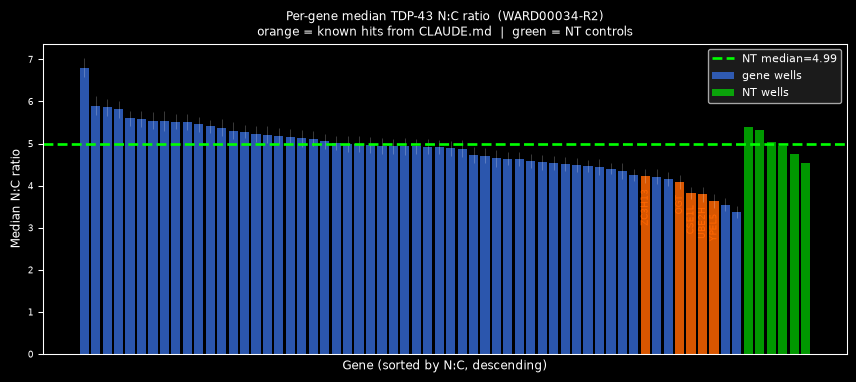

Saved: 04_per_gene_nc_ratio.png


In [6]:
# Per-gene median N:C, sorted descending, NT highlighted
gene_stats = (tdp_filt
              .groupby('Gene')['NC_ratio']
              .agg(['median','count','std'])
              .query('count >= 50')
              .sort_values('median', ascending=False)
              .reset_index())

nt_genes   = gene_stats[gene_stats.Gene.str.startswith('NT')]
gene_stats2= gene_stats[~gene_stats.Gene.str.startswith('NT')].sort_values('median', ascending=False)

nt_median_all = nt_genes['median'].median()
print(f"Genes with ≥50 cells: {len(gene_stats)}")
print(f"NT variants: {len(nt_genes)}, pooled median NC = {nt_median_all:.2f}")
print()
print("Top-10 highest N:C (nuclear):")
print(gene_stats.head(10)[['Gene','median','count']].to_string(index=False))
print()
print("Top-10 lowest N:C (cytoplasmic):")
print(gene_stats.tail(10)[['Gene','median','count']].sort_values('median').to_string(index=False))

KNOWN_HITS = ['CSE1L','YPEL5','UBE2H','MAEA','ZC3H13','OGT']

fig, ax = plt.subplots(figsize=(10.8, 4.2), facecolor=BG, dpi=DPI)
ax.set_facecolor(BG); ax.tick_params(colors=FG, labelsize=7)
ax.xaxis.label.set_color(FG); ax.yaxis.label.set_color(FG)
for s in ax.spines.values(): s.set_color(FG)

# Plot gene bars (sorted by median)
gene_sorted = gene_stats2.sort_values('median', ascending=False)
colors_bar = []
for g in gene_sorted.Gene:
    if g in KNOWN_HITS: colors_bar.append('#ff6600')
    else:               colors_bar.append('#3366cc')

ax.bar(range(len(gene_sorted)), gene_sorted['median'], color=colors_bar, alpha=0.85, edgecolor='none', label='gene wells')
# Add error bars (SEM)
errs = gene_sorted['std'] / np.sqrt(gene_sorted['count'])
ax.errorbar(range(len(gene_sorted)), gene_sorted['median'], yerr=errs,
            fmt='none', ecolor='#ffffff55', elinewidth=0.5, capsize=0)

# NT median line
ax.axhline(nt_median_all, color='lime', ls='--', lw=2, label=f'NT median={nt_median_all:.2f}')

# NT bars on same plot
ax.bar(range(len(gene_sorted), len(gene_sorted)+len(nt_genes)),
       nt_genes.sort_values('median', ascending=False)['median'],
       color='lime', alpha=0.6, edgecolor='none', label='NT wells')

# Label known hits
for hit in KNOWN_HITS:
    hit_row = gene_sorted[gene_sorted.Gene == hit]
    if not hit_row.empty:
        idx = hit_row.index[0]
        pos = gene_sorted.index.get_loc(idx)
        ax.text(pos, hit_row['median'].values[0] - 0.3, hit, color='#ff6600',
                fontsize=7, ha='center', va='top', rotation=90)

ax.set_xlabel('Gene (sorted by N:C, descending)', fontsize=9)
ax.set_ylabel('Median N:C ratio', fontsize=9)
ax.set_title('Per-gene median TDP-43 N:C ratio  (WARD00034-R2)\n'
             'orange = known hits from CLAUDE.md  |  green = NT controls', color=FG, fontsize=9)
ax.set_xticks([]); ax.legend(fontsize=8, labelcolor=FG, facecolor='#222')

fig.savefig(FIGDIR / '04_per_gene_nc_ratio.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: 04_per_gene_nc_ratio.png")

## Representative Cell Montage — Top-3 Hit Genes vs NT

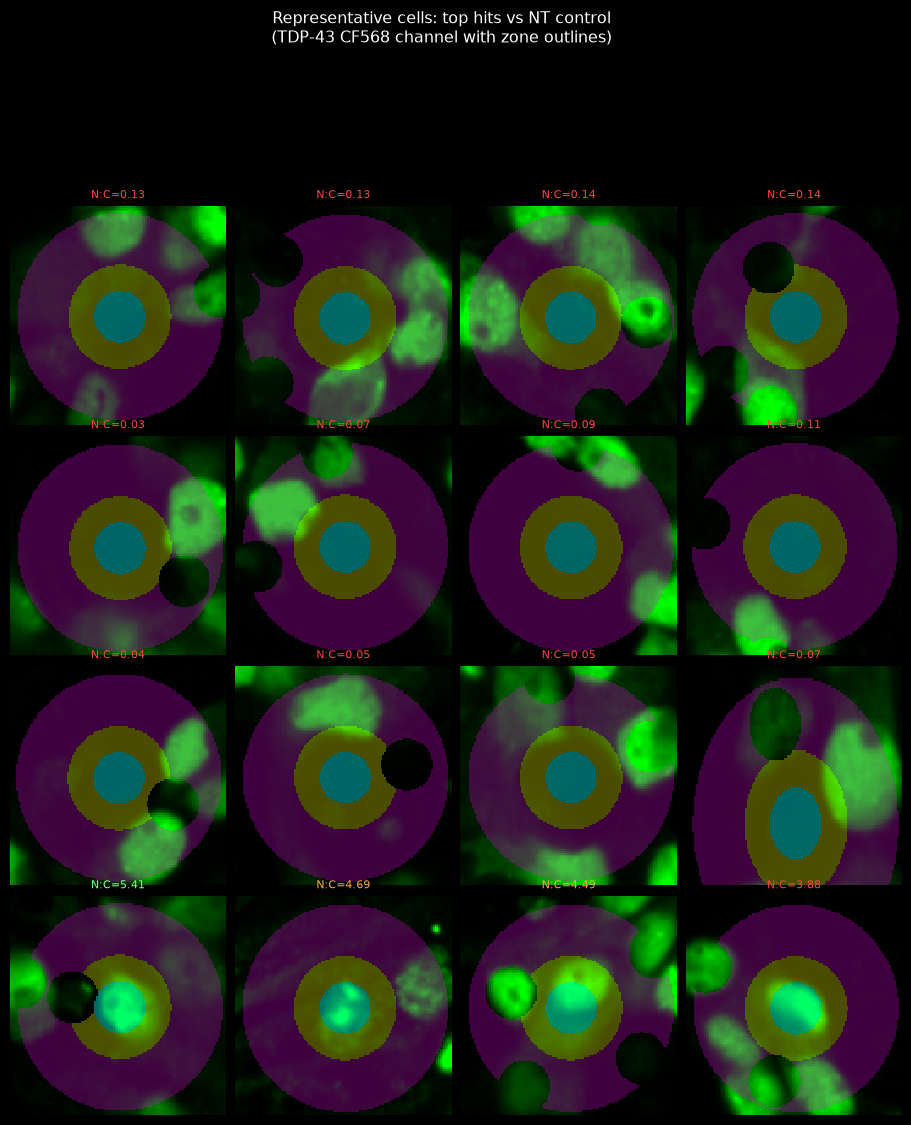

Saved: 05_representative_cells_montage.png
NT baseline: 4.99


In [7]:
# Load TDP-43 TIFF for each gene's best well and show 3-4 cells per gene
def build_masks_local(cy, cx, others_yx, r_nuc, r_adj, r_cyto, y0, y1, x0, x1):
    yy, xx = np.ogrid[y0:y1, x0:x1]
    d2 = (yy-cy)**2 + (xx-cx)**2
    nuc  = d2 <= r_nuc**2
    adj  = (d2 > r_nuc**2) & (d2 <= r_adj**2)
    cyto = (d2 > r_adj**2) & (d2 <= r_cyto**2)
    if len(others_yx):
        other = np.zeros_like(nuc)
        for oy, ox in others_yx:
            other |= (yy-oy)**2+(xx-ox)**2 <= r_nuc**2
        adj &= ~other; cyto &= ~other
    return nuc, adj, cyto

GENES_MONTAGE = ['CSE1L', 'YPEL5', 'UBE2H', 'NT18']
CELLS_PER_GENE = 4
CROP_MON = 64  # px half-width
K2G = LinearSegmentedColormap.from_list('k2g', ['black','lime'])

fig, axs = plt.subplots(len(GENES_MONTAGE), CELLS_PER_GENE,
                         figsize=(CELLS_PER_GENE*3, len(GENES_MONTAGE)*3.2),
                         facecolor=BG, dpi=DPI)
fig.suptitle('Representative cells: top hits vs NT control\n(TDP-43 CF568 channel with zone outlines)',
             color=FG, y=1.01)
plt.subplots_adjust(hspace=0.05, wspace=0.04, top=0.85)

for gi, gene in enumerate(GENES_MONTAGE):
    gene_cells = tdp_filt[tdp_filt.Gene == gene].copy()
    # For low-NC genes, pick lowest NC; for NT pick median range
    if gene.startswith('NT'):
        med = gene_cells.NC_ratio.median()
        gene_cells = gene_cells[(gene_cells.NC_ratio > med*0.8) & (gene_cells.NC_ratio < med*1.2)]
    else:
        gene_cells = gene_cells.sort_values('NC_ratio').head(CELLS_PER_GENE * 3)
    gene_cells = gene_cells.drop_duplicates(subset=['Row','Column','Frame']).head(CELLS_PER_GENE)

    # Cache TDP-43 planes per site
    tdp_cache = {}

    for ci in range(CELLS_PER_GENE):
        ax = axs[gi, ci]
        ax.set_facecolor(BG); ax.axis('off')
        for s in ax.spines.values(): s.set_color(FG)

        if ci == 0:
            ax.set_ylabel(gene, color='lime' if gene.startswith('NT') else '#ff6600',
                          fontsize=10, fontweight='bold', rotation=0, labelpad=50, va='center')

        if ci >= len(gene_cells):
            continue

        cell = gene_cells.iloc[ci]
        row_c, col_c, frame_c = int(cell.Row), int(cell.Column), int(cell.Frame)
        nc_c = float(cell.NC_ratio)
        cy_c, cx_c = float(cell['centroid-0']), float(cell['centroid-1'])
        bf   = int(cell.best_focus_plane)

        site_key = (row_c, col_c, frame_c)
        if site_key not in tdp_cache:
            tdir = IMG_DIR / f'r{row_c:02d}c{col_c:02d}'
            tpaths = sorted(tdir.glob(f'r{row_c:02d}c{col_c:02d}f{frame_c:02d}p*-ch03t01.tiff'))
            if tpaths:
                all_planes = [tifffile.imread(p).astype(np.float32) for p in tpaths]
                focus_s = [np.var(laplace(p)) for p in all_planes]
                tdp_cache[site_key] = all_planes[int(np.argmax(focus_s))]
            else:
                tdp_cache[site_key] = None

        tdp_img_m = tdp_cache[site_key]
        if tdp_img_m is None:
            ax.text(0.5, 0.5, 'no TIFF', ha='center', va='center', color=FG,
                    transform=ax.transAxes, fontsize=8)
            continue

        y0c, y1c = int(max(0, cy_c-CROP_MON)), int(min(tdp_img_m.shape[0], cy_c+CROP_MON))
        x0c, x1c = int(max(0, cx_c-CROP_MON)), int(min(tdp_img_m.shape[1], cx_c+CROP_MON))
        crop = tdp_img_m[y0c:y1c, x0c:x1c]

        site_tdp = tdp_filt[(tdp_filt.Row==row_c)&(tdp_filt.Column==col_c)&(tdp_filt.Frame==frame_c)]
        others_yx = [(float(r['centroid-0']), float(r['centroid-1'])) for _, r in site_tdp.iterrows()
                     if abs(r['centroid-0']-cy_c)<(R_CYTO+R_NUC) and abs(r['centroid-1']-cx_c)<(R_CYTO+R_NUC)]

        nuc_m, adj_m, cyto_m = build_masks_local(cy_c, cx_c, others_yx, R_NUC, R_ADJ, R_CYTO, y0c, y1c, x0c, x1c)

        vmin, vmax = np.percentile(crop, [1, 99.5])
        ax.imshow(crop, cmap=K2G, vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')

        ov = np.zeros((*crop.shape, 4), dtype=np.float32)
        ov[nuc_m]  = [0, 1, 1, 0.4]
        ov[adj_m]  = [1, 1, 0, 0.3]
        ov[cyto_m] = [1, 0, 1, 0.25]
        ax.imshow(ov, aspect='auto', interpolation='none')

        nc_col = '#ff4444' if nc_c < nt_median_all * 0.8 else '#ffaa44' if nc_c < nt_median_all else '#88ff88'
        ax.set_title(f'N:C={nc_c:.2f}', color=nc_col, fontsize=8)

fig.savefig(FIGDIR / '05_representative_cells_montage.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: 05_representative_cells_montage.png")
print(f"NT baseline: {nt_median_all:.2f}")

In [8]:
# Verify figures
pngs = sorted(FIGDIR.glob('*.png'))
empty = [p for p in pngs if p.stat().st_size == 0]
assert pngs,  f"No figures written to {FIGDIR}"
assert not empty, f"0-byte figures: {empty}"
print(f"OK: {len(pngs)} figures in {FIGDIR.name}/")
for p in pngs:
    print(f"  {p.name}  ({p.stat().st_size//1024} KB)")

OK: 5 figures in phase_D/
  01_per_compartment_intensity.png  (32 KB)
  02_nc_ratio_distribution.png  (31 KB)
  03_background_subtraction.png  (50 KB)
  04_per_gene_nc_ratio.png  (24 KB)
  05_representative_cells_montage.png  (209 KB)
